# Autism eye tracking: klasifikasi scanpath dengan evaluasi tingkat anak

Dataset Carette berisi 547 citra scanpath dari 54 partisipan, bukan 547 anak independen.
Satu anak menyumbang antara 1 sampai 23 rekaman. Karena itu seluruh pipeline di notebook ini
memperlakukan anak sebagai unit analisis, bukan citra.

Konsekuensinya: unit split adalah `participant_id` yang diekstrak dari suffix nama file, loss
dibobot equal-child sehingga setiap anak menyumbang total bobot yang sama, evaluasi dilakukan
di tingkat anak dengan probabilitas rekaman dirata-ratakan lebih dulu, threshold dipilih pada
validation tingkat anak, dan pelaporan memakai 5 outer fold (mean +/- SD) plus bootstrap CI
atas partisipan.

Ini eksperimen riset, bukan alat diagnosis. Model di notebook ini tidak diekspor ke webapp
Neurogaze. Citra Carette adalah raster scanpath 250 Hz pada anak usia sekolah (rata-rata
+/-7,9 tahun), sedangkan runtime web menerima koordinat iris kamera 20-30 Hz pada balita.
Perbandingan lintas domain memerlukan studi jembatan tersendiri.

## 1. Kontrak eksperimen yang dikunci

- Label dibaca hanya dari nama folder (`TCImages` / `TSImages`), bukan dari filename.
- Unit split, pembobotan, pemilihan threshold, dan pelaporan metrik adalah anak.
- dHash hanya mengaudit duplikat visual. dHash tidak pernah menggantikan participant ID.
- Test setiap fold dikunci sampai akhir fold tersebut. Threshold dan mode inferensi hanya
  berasal dari validation.
- Seluruh 5 outer fold dijalankan. Tidak ada pemilihan fold terbaik.

In [1]:
# Kaggle environment / reproducibility
import os, re, random, warnings, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             f1_score, accuracy_score, balanced_accuracy_score,
                             roc_curve, average_precision_score)

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS_HEAD = 20
EPOCHS_FINE_TUNE = 12
N_OUTER_FOLDS = 5
AUTOTUNE = tf.data.AUTOTUNE

# flag eksperimen
DROP_HASH_CONFLICTS    = False  # dHash dipakai sebagai audit, bukan sebagai filter baris
USE_EQUAL_CHILD_WEIGHT = True   # setiap anak menyumbang total bobot training yang sama
SELECTION_METRIC       = 'balanced_accuracy'   # 'accuracy' | 'balanced_accuracy' | 'youden'
RUN_GROUPING_ABLATION  = True   # ulangi pipeline dengan grouping duplikat visual
N_BOOTSTRAP            = 2000

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass
warnings.filterwarnings('ignore')
print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Manifest dan ekstraksi participant ID

Dataset Carette memberi nama file dengan pola `T{C,S}###_PP.png`. Bagian `###` adalah nomor
rekaman, dan suffix `_PP` adalah identitas partisipan. Suffix `01`-`29` dipakai kelompok ASD
(`TSImages`) dan `30`-`59` dipakai kelompok kontrol (`TCImages`), sehingga suffix sudah unik
antar kelompok.

Tanpa ekstraksi ini, tidak ada cara membentuk split yang benar-benar memisahkan anak.

In [2]:
INPUT_ROOT = Path('/kaggle/input')
if not INPUT_ROOT.exists():
    raise FileNotFoundError('Notebook ini ditujukan untuk Kaggle. Tambahkan dataset lewat Add Input.')

image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
all_images = [p for p in INPUT_ROOT.rglob('*') if p.is_file() and p.suffix.lower() in image_exts]

def label_from_path(path: Path):
    parts = {part.casefold() for part in path.parts}
    if 'tcimages' in parts:
        return 0, 'Non-ASD'
    if 'tsimages' in parts:
        return 1, 'ASD'
    return None, None

FNAME = re.compile(r'^T([CS])(\d+)_(\d+)\.[A-Za-z]+$')

rows, unparsed = [], []
for path in all_images:
    label, class_name = label_from_path(path)
    if label is None:
        continue
    m = FNAME.match(path.name)
    if m is None:
        unparsed.append(path.name); continue
    rows.append({
        'path': str(path),
        'label': label,
        'class_name': class_name,
        'record_no': m.group(2),
        'participant_id': f'{m.group(1).upper()}{int(m.group(3)):02d}',
    })

if unparsed:
    raise RuntimeError(f'{len(unparsed)} file tidak cocok pola Carette, contoh: {unparsed[:5]}')

df = pd.DataFrame(rows)
if df.empty:
    raise RuntimeError('Folder TCImages/TSImages tidak ditemukan. Periksa Add Input.')

n_part = df.participant_id.nunique()
print(f'Total citra      : {len(df)}')
print(f'Total partisipan : {n_part}')
assert n_part == 54, f'Diharapkan 54 partisipan sesuai protokol Carette, ditemukan {n_part}'

bad = df.groupby('participant_id').label.nunique()
assert bad.max() == 1, f'Partisipan berlabel ganda: {bad[bad>1].index.tolist()}'

child = df.drop_duplicates('participant_id')[['participant_id','label','class_name']]
print('\nPartisipan per kelas:')
print(child.class_name.value_counts().to_string())
print('\nCitra per kelas:')
print(df.class_name.value_counts().to_string())

Total citra      : 547
Total partisipan : 54

Partisipan per kelas:
class_name
Non-ASD    28
ASD        26

Citra per kelas:
class_name
Non-ASD    328
ASD        219


count    54.00000
mean     10.12963
std       5.48427
min       1.00000
25%       6.25000
50%      10.00000
75%      14.00000
max      23.00000


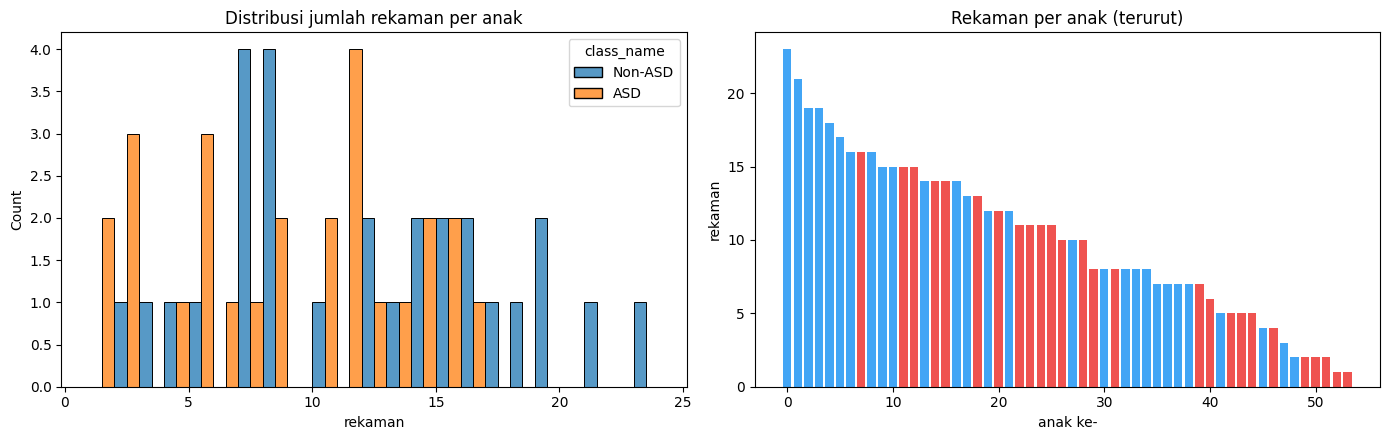


Satu anak menyumbang hingga 23 citra (4.2% dari seluruh dataset).


In [3]:
# Distribusi jumlah rekaman per anak. Ini alasan split per-citra tidak sah.
rec_per_child = df.groupby(['participant_id','class_name']).size().rename('n_records').reset_index()
print(rec_per_child.n_records.describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(data=rec_per_child, x='n_records', hue='class_name', multiple='dodge',
             bins=range(1, rec_per_child.n_records.max()+2), ax=axes[0])
axes[0].set_title('Distribusi jumlah rekaman per anak'); axes[0].set_xlabel('rekaman')

order = rec_per_child.sort_values('n_records', ascending=False)
axes[1].bar(range(len(order)), order.n_records,
            color=order.class_name.map({'ASD':'#EF5350','Non-ASD':'#42A5F5'}))
axes[1].set_title('Rekaman per anak (terurut)'); axes[1].set_xlabel('anak ke-'); axes[1].set_ylabel('rekaman')
plt.tight_layout(); plt.savefig('eda_rekaman_per_anak.png', dpi=150); plt.show()

print(f'\nSatu anak menyumbang hingga {rec_per_child.n_records.max()} citra '
      f'({rec_per_child.n_records.max()/len(df)*100:.1f}% dari seluruh dataset).')

## 3. dHash sebagai audit kualitas

dHash membandingkan pola visual setelah citra dikecilkan. Di notebook ini ia menjawab dua
pertanyaan audit saja:

1. Berapa banyak duplikat visual yang ada, dan apakah duplikat itu berada dalam satu anak?
2. Apakah ada konflik label pada visual yang sama?

dHash tidak dipakai sebagai unit split. Group dHash hampir sama banyaknya dengan jumlah citra,
sehingga memakainya sebagai group praktis setara dengan split acak per-citra dan tidak
memisahkan identitas anak. Penghapusan baris dikendalikan `DROP_HASH_CONFLICTS` dan
default-nya mati, karena setelah grouping berbasis anak konflik dHash bukan lagi sumber
kebocoran.

In [4]:
def dhash(path, size=8):
    with Image.open(path) as im:
        gray = im.convert('L').resize((size + 1, size), Image.Resampling.LANCZOS)
        pixels = np.asarray(gray, dtype=np.int16)
    bits = pixels[:, 1:] > pixels[:, :-1]
    return np.packbits(bits.astype(np.uint8)).tobytes().hex()

hashes, bad = [], []
for path in df.path:
    try:
        hashes.append(dhash(path)); bad.append(False)
    except Exception as exc:
        print('Unreadable:', path, '|', exc); hashes.append(None); bad.append(True)

df['dhash'] = hashes
df = df.loc[~pd.Series(bad)].copy().reset_index(drop=True)
df['dhash_group'] = pd.factorize(df['dhash'])[0]

# Audit 1 — duplikat visual lintas anak
dup = df.groupby('dhash').agg(n=('path','size'), n_child=('participant_id','nunique'))
cross_child = dup[(dup.n > 1) & (dup.n_child > 1)]
print(f'Group dHash total          : {df.dhash_group.nunique()}')
print(f'Group dengan >1 citra      : {(dup.n > 1).sum()}')
print(f'Group menyeberangi anak    : {len(cross_child)}')

# Audit 2 — konflik label pada visual identik
conflicts = df.groupby('dhash').label.nunique()
conflict_hashes = conflicts[conflicts > 1].index
print(f'Group dHash konflik label  : {len(conflict_hashes)} '
      f'({df.dhash.isin(conflict_hashes).sum()} citra)')

if len(conflict_hashes):
    df[df.dhash.isin(conflict_hashes)].to_csv('/kaggle/working/audit_dhash_konflik.csv', index=False)
    if DROP_HASH_CONFLICTS:
        df = df.loc[~df.dhash.isin(conflict_hashes)].copy().reset_index(drop=True)
        print('DROP_HASH_CONFLICTS aktif: baris konflik dibuang.')
    else:
        print('DROP_HASH_CONFLICTS mati: baris konflik dipertahankan, hanya dicatat.')

print(f'\nCitra dipakai: {len(df)} | anak: {df.participant_id.nunique()}')
print(f'Rasio group dHash terhadap citra: {df.dhash_group.nunique()}/{len(df)} '
      f'= {df.dhash_group.nunique()/len(df):.3f}  <-- mendekati 1 berarti grouping dHash '
      f'praktis setara split per-citra')

Group dHash total          : 481
Group dengan >1 citra      : 34
Group menyeberangi anak    : 32
Group dHash konflik label  : 10 (41 citra)
DROP_HASH_CONFLICTS mati: baris konflik dipertahankan, hanya dicatat.

Citra dipakai: 547 | anak: 54
Rasio group dHash terhadap citra: 481/547 = 0.879  <-- mendekati 1 berarti grouping dHash praktis setara split per-citra


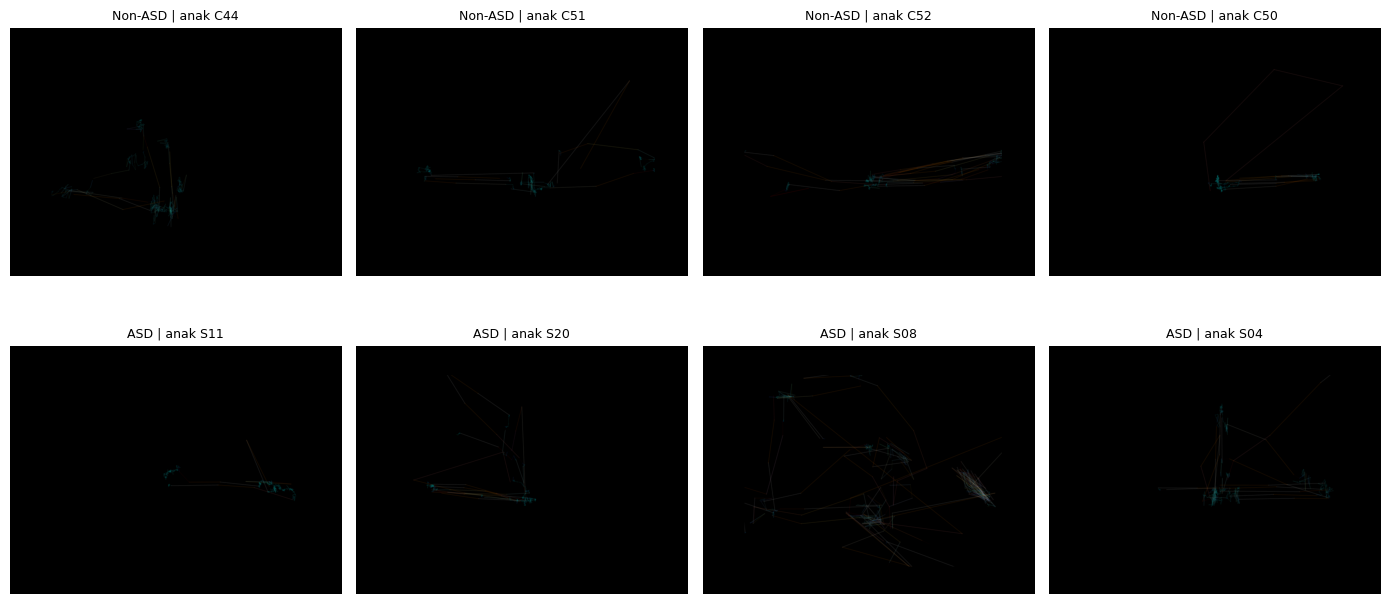

In [5]:
# Sanity check visual: label harus cocok dengan gambar, dan ID anak tertera.
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for label, row_axes in zip([0, 1], axes):
    sample = df[df.label.eq(label)].sample(4, random_state=SEED)
    for ax, (_, row) in zip(row_axes, sample.iterrows()):
        ax.imshow(Image.open(row.path).convert('RGB'))
        ax.set_title(f'{row.class_name} | anak {row.participant_id}', fontsize=9)
        ax.axis('off')
plt.tight_layout(); plt.savefig('sanity_label.png', dpi=140); plt.show()

## 4. Berapa banyak identitas anak yang bocor jika grouping salah?

Sebelum melatih apa pun, bandingkan dua skema grouping dan hitung berapa anak yang muncul di
lebih dari satu split.

In [6]:
def split_indices(frame, group_values, seed=SEED):
    outer = StratifiedGroupKFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=seed)
    return list(outer.split(frame, y=frame.label, groups=group_values))

def overlap_report(frame, group_col, seed=SEED):
    folds = split_indices(frame, frame[group_col].values, seed)
    trainval_idx, test_idx = folds[0]
    tv = frame.iloc[trainval_idx].reset_index(drop=True)
    te = frame.iloc[test_idx].reset_index(drop=True)
    inner = StratifiedGroupKFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=seed + 1)
    tr_idx, va_idx = next(inner.split(tv, y=tv.label, groups=tv[group_col].values))
    tr, va = tv.iloc[tr_idx], tv.iloc[va_idx]
    out = {}
    for a, b, na, nb in [(tr, va, 'train', 'validation'), (tr, te, 'train', 'test'),
                         (va, te, 'validation', 'test')]:
        out[f'{na}/{nb}'] = len(set(a.participant_id) & set(b.participant_id))
    sizes = {'train': tr.participant_id.nunique(), 'validation': va.participant_id.nunique(),
             'test': te.participant_id.nunique()}
    return out, sizes

ov_hash, sz_hash = overlap_report(df, 'dhash_group')
ov_part, sz_part = overlap_report(df, 'participant_id')

leak = pd.DataFrame({'grouping duplikat visual': ov_hash, 'grouping partisipan': ov_part})
leak.index.name = 'anak yang muncul di kedua split'
print(leak.to_string())
print('\nJumlah anak unik per split:')
print(pd.DataFrame({'duplikat visual': sz_hash, 'partisipan': sz_part}).to_string())
leak.to_csv('/kaggle/working/audit_kebocoran_split.csv')

                                 grouping duplikat visual  grouping partisipan
anak yang muncul di kedua split                                               
train/validation                                       39                    0
train/test                                             41                    0
validation/test                                        35                    0

Jumlah anak unik per split:
            duplikat visual  partisipan
train                    51          35
validation               42           9
test                     42          10


## 5. Split terisolasi per anak

Outer fold membentuk test per anak; inner fold membentuk validation per anak. Assertion
memeriksa `participant_id`, bukan hash citra.

In [7]:
def build_splits(frame, group_col, fold_id, seed=SEED):
    folds = split_indices(frame, frame[group_col].values, seed)
    trainval_idx, test_idx = folds[fold_id]
    trainval = frame.iloc[trainval_idx].reset_index(drop=True)
    test_df  = frame.iloc[test_idx].reset_index(drop=True)

    inner = StratifiedGroupKFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=seed + 1 + fold_id)
    tr_idx, va_idx = next(inner.split(trainval, y=trainval.label, groups=trainval[group_col].values))
    train_df = trainval.iloc[tr_idx].reset_index(drop=True)
    val_df   = trainval.iloc[va_idx].reset_index(drop=True)

    if group_col == 'participant_id':
        splits = {'train': train_df, 'validation': val_df, 'test': test_df}
        for a, b in [('train','validation'), ('train','test'), ('validation','test')]:
            ov = set(splits[a].participant_id) & set(splits[b].participant_id)
            assert not ov, f'LEAKAGE partisipan {a}/{b}: {len(ov)} anak'
    return train_df, val_df, test_df

tr0, va0, te0 = build_splits(df, 'participant_id', 0)
for name, f in [('train', tr0), ('validation', va0), ('test', te0)]:
    print(f'{name:11} citra={len(f):4} | anak={f.participant_id.nunique():3} | '
          f'ASD(anak)={f.drop_duplicates("participant_id").label.mean():.3f}')
print('PASS: tidak ada anak yang menyeberang split.')

train       citra= 358 | anak= 35 | ASD(anak)=0.400
validation  citra=  98 | anak=  9 | ASD(anak)=0.556
test        citra=  91 | anak= 10 | ASD(anak)=0.700
PASS: tidak ada anak yang menyeberang split.


## 6. `tf.data` dengan bobot equal-child

Bobot setiap citra adalah `class_weight[label] / jumlah_rekaman_anak_itu`, dinormalisasi
sehingga rata-ratanya 1. `class_weight` dihitung dari jumlah anak per kelas, bukan jumlah
citra. Dengan begitu anak yang punya 23 rekaman tidak 23x lebih berpengaruh terhadap loss
daripada anak yang punya 1 rekaman.

Augmentasi hanya aktif pada train. Flip horizontal sengaja tidak dipakai karena arah pola
scanpath dapat bermakna.

In [8]:
augment = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05, fill_mode='reflect'),
    tf.keras.layers.RandomTranslation(0.05, 0.05, fill_mode='reflect'),
    tf.keras.layers.RandomZoom(0.10, 0.10, fill_mode='reflect'),
    tf.keras.layers.RandomContrast(0.10),
], name='train_augmentation')

def _decode(path):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE), antialias=True)
    return tf.cast(image, tf.float32)

def equal_child_weights(frame):
    kids = frame.drop_duplicates('participant_id')
    cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=kids.label.values)
    n_rec = frame.participant_id.map(frame.participant_id.value_counts()).values
    w = frame.label.map({0: cw[0], 1: cw[1]}).values.astype('float64')
    if USE_EQUAL_CHILD_WEIGHT:
        w = w / n_rec
    return (w / w.mean()).astype('float32'), dict(zip([0, 1], cw))

def make_ds(frame, training=False, tta=False, weights=None):
    paths = frame.path.values
    labels = frame.label.values.astype('float32')
    if weights is None:
        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        if training:
            ds = ds.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(lambda p, y: (_decode(p), y), num_parallel_calls=AUTOTUNE)
        if training or tta:
            ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
    else:
        ds = tf.data.Dataset.from_tensor_slices((paths, labels, weights))
        if training:
            ds = ds.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(lambda p, y, w: (_decode(p), y, w), num_parallel_calls=AUTOTUNE)
        if training or tta:
            ds = ds.map(lambda x, y, w: (augment(x, training=True), y, w), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

w0, cw0 = equal_child_weights(tr0)
chk = tr0.copy(); chk['w'] = w0
per_child = chk.groupby(['participant_id','label']).w.sum().reset_index()
print('class_weight (dihitung dari jumlah anak):', {k: round(v, 4) for k, v in cw0.items()})
print('\nTotal bobot per anak, dilihat di dalam masing-masing kelas:')
for lbl, name in [(0, 'Non-ASD'), (1, 'ASD')]:
    s = per_child[per_child.label == lbl].w
    print(f'  {name:8}: min {s.min():.3f} | max {s.max():.3f} | SD {s.std():.4f}  (n={len(s)} anak)')
print('SD di dalam kelas harus nol: setiap anak menyumbang bobot total yang sama.')
print('\nTotal bobot per kelas:', chk.groupby("label").w.sum().round(2).to_dict(), ' (harus seimbang)')

# Pembanding: bobot per-citra membuat anak dengan banyak rekaman mendominasi loss.
cw_img = compute_class_weight('balanced', classes=np.array([0,1]), y=tr0.label.values)
old_child = tr0.assign(w=tr0.label.map({0: cw_img[0], 1: cw_img[1]}).values).groupby('participant_id').w.sum()
print(f'\nJika bobot dihitung per citra: total bobot anak min {old_child.min():.2f} '
      f'max {old_child.max():.2f} — rasio {old_child.max()/old_child.min():.1f}x')

class_weight (dihitung dari jumlah anak): {0: np.float64(0.8333), 1: np.float64(1.25)}

Total bobot per anak, dilihat di dalam masing-masing kelas:
  Non-ASD : min 8.524 | max 8.524 | SD 0.0000  (n=21 anak)
  ASD     : min 12.786 | max 12.786 | SD 0.0000  (n=14 anak)
SD di dalam kelas harus nol: setiap anak menyumbang bobot total yang sama.

Total bobot per kelas: {0: 179.0, 1: 179.0}  (harus seimbang)

Jika bobot dihitung per citra: total bobot anak min 1.44 max 24.63 — rasio 17.1x


I0000 00:00:1786109208.537751      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786109208.540895      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 7. Model dan fungsi satu fold

Tahap pertama membekukan EfficientNetB0 agar head belajar stabil. Tahap kedua membuka 25%
layer teratas dengan learning rate kecil dan BatchNormalization tetap dalam mode inferensi.

Backbone diambil dengan mencari sub-model di dalam `model.layers`. Indeks layer tidak dijamin
stabil setelah `load_model`, sedangkan backbone selalu satu-satunya layer berupa `keras.Model`.

In [9]:
def get_backbone(m):
    # Ambil sub-model EfficientNet tanpa bergantung pada indeks atau nama layer.
    subs = [l for l in m.layers if isinstance(l, tf.keras.Model)]
    if len(subs) != 1:
        raise RuntimeError(f'Diharapkan tepat satu sub-model backbone, ditemukan {len(subs)}')
    return subs[0]

def build_model():
    try:
        backbone = tf.keras.applications.EfficientNetB0(
            include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
    except Exception as exc:
        print('ImageNet weights unavailable, random init:', exc)
        backbone = tf.keras.applications.EfficientNetB0(
            include_top=False, weights=None, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    backbone.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image')
    x = backbone(inputs, training=False)     # EfficientNet menormalisasi internal, input [0,255]
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.35)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid', name='asd_probability')(x)
    return tf.keras.Model(inputs, outputs)

METRICS = lambda: [tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                   tf.keras.metrics.AUC(name='auc')]

def aggregate_children(frame, prob):
    out = frame[['participant_id', 'label']].copy()
    out['p'] = prob
    return (out.groupby('participant_id')
              .agg(label=('label', 'first'), p=('p', 'mean'), n_records=('p', 'size'))
              .reset_index())

def score_at(y, p, t):
    pred = (p >= t).astype(int)
    return {'accuracy': accuracy_score(y, pred),
            'balanced_accuracy': balanced_accuracy_score(y, pred),
            'youden': balanced_accuracy_score(y, pred) * 2 - 1}

In [10]:
def run_fold(frame, group_col, fold_id, verbose=0):
    t0 = time.time()
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED + fold_id)

    train_df, val_df, test_df = build_splits(frame, group_col, fold_id)
    w_train, _ = equal_child_weights(train_df)

    train_ds = make_ds(train_df, training=True, weights=w_train)
    val_ds   = make_ds(val_df)
    test_ds  = make_ds(test_df)

    ckpt = f'/kaggle/working/fold{fold_id}_{group_col}.keras'
    cbs = [tf.keras.callbacks.ModelCheckpoint(ckpt, monitor='val_auc', mode='max',
                                              save_best_only=True, verbose=0),
           tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=5,
                                            restore_best_weights=True, verbose=0),
           tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2,
                                                min_lr=1e-6, verbose=0)]

    model = build_model()
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=METRICS())
    h_head = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
                       callbacks=cbs, verbose=verbose)
    auc_after_head = max(h_head.history['val_auc'])

    # Fine-tuning terkontrol
    model = tf.keras.models.load_model(ckpt)
    backbone = get_backbone(model)
    backbone.trainable = True
    cut = int(len(backbone.layers) * 0.75)
    for layer in backbone.layers[:cut]:
        layer.trainable = False
    for layer in backbone.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='binary_crossentropy', metrics=METRICS())
    h_ft = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINE_TUNE,
                     callbacks=cbs, verbose=verbose)
    auc_after_ft = max(h_ft.history['val_auc'])
    model = tf.keras.models.load_model(ckpt)

    # pilih mode inferensi dan threshold pada validation, level anak
    def child_prob(frame_, tta):
        if tta:
            passes = [model.predict(make_ds(frame_), verbose=0).ravel()]
            for _ in range(6):
                passes.append(model.predict(make_ds(frame_, tta=True), verbose=0).ravel())
            p = np.mean(passes, axis=0)
        else:
            p = model.predict(make_ds(frame_), verbose=0).ravel()
        return aggregate_children(frame_, p)

    val_plain, val_tta = child_prob(val_df, False), child_prob(val_df, True)
    auc_val = {'plain': roc_auc_score(val_plain.label, val_plain.p),
               'tta_6': roc_auc_score(val_tta.label, val_tta.p)}
    mode = max(auc_val, key=auc_val.get)
    val_child = val_plain if mode == 'plain' else val_tta

    grid = np.arange(0.05, 0.96, 0.01)
    scores = [score_at(val_child.label.values, val_child.p.values, t)[SELECTION_METRIC] for t in grid]
    thr = float(grid[int(np.argmax(scores))])

    # --- evaluasi test, dikunci ---
    test_child = child_prob(test_df, mode == 'tta_6')
    auc_test = roc_auc_score(test_child.label, test_child.p)
    m = score_at(test_child.label.values, test_child.p.values, thr)

    test_child = test_child.assign(fold=fold_id, threshold=thr, mode=mode)
    return {'fold': fold_id, 'group_col': group_col, 'mode': mode, 'threshold': thr,
            'auc_val': auc_val[mode], 'auc_test': auc_test,
            'acc_test': m['accuracy'], 'bacc_test': m['balanced_accuracy'],
            'auc_val_after_head': auc_after_head, 'auc_val_after_finetune': auc_after_ft,
            'n_train_child': train_df.participant_id.nunique(),
            'n_val_child': val_df.participant_id.nunique(),
            'n_test_child': test_child.participant_id.nunique(),
            'secs': time.time() - t0}, test_child

print('run_fold siap.')

run_fold siap.


## 8. Menjalankan 5 outer fold

Setiap anak muncul tepat satu kali sebagai data test di seluruh 5 fold, sehingga probabilitas
out-of-fold dapat digabung menjadi satu estimasi tingkat anak untuk 54 anak.

In [11]:
res_part, oof_part = [], []
for k in range(N_OUTER_FOLDS):
    r, tc = run_fold(df, 'participant_id', k, verbose=0)
    res_part.append(r); oof_part.append(tc)
    print(f"fold {k}: mode={r['mode']:6} thr={r['threshold']:.2f} "
          f"AUC_val={r['auc_val']:.4f} AUC_test={r['auc_test']:.4f} "
          f"bAcc_test={r['bacc_test']:.4f} anak_test={r['n_test_child']} "
          f"({r['secs']:.0f}s)")

res_part = pd.DataFrame(res_part)
oof_part = pd.concat(oof_part, ignore_index=True)
res_part.to_csv('/kaggle/working/hasil_per_fold_participant.csv', index=False)
oof_part.to_csv('/kaggle/working/oof_participant.csv', index=False)

print(f'\nAnak unik pada gabungan out-of-fold: {oof_part.participant_id.nunique()} '
      f'(diharapkan {df.participant_id.nunique()})')
print('\nMean +/- SD lintas fold:')
for col in ['auc_test', 'acc_test', 'bacc_test']:
    print(f'  {col:11}: {res_part[col].mean():.4f} +/- {res_part[col].std():.4f}')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


2026-08-07 13:26:54.832407: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_10}}
E0000 00:00:1786109223.350255      22 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOpti

fold 0: mode=plain  thr=0.35 AUC_val=1.0000 AUC_test=0.7619 bAcc_test=0.5952 anak_test=10 (348s)


2026-08-07 13:32:39.395932: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_10}}
E0000 00:00:1786109567.553462      22 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimi

fold 1: mode=plain  thr=0.51 AUC_val=0.8333 AUC_test=0.7333 bAcc_test=0.6333 anak_test=11 (212s)


...

fold 2: mode=plain  thr=0.58 AUC_val=1.0000 AUC_test=1.0000 bAcc_test=0.8000 anak_test=11 (182s)


2026-08-07 13:39:13.818421: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_10}}
E0000 00:00:1786109962.128083      22 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimi

fold 3: mode=plain  thr=0.34 AUC_val=0.6875 AUC_test=1.0000 bAcc_test=0.6667 anak_test=11 (206s)


2026-08-07 13:42:40.294182: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_10}}
E0000 00:00:1786110168.566961      22 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimi

fold 4: mode=plain  thr=0.60 AUC_val=1.0000 AUC_test=0.9286 bAcc_test=0.8036 anak_test=11 (224s)

Anak unik pada gabungan out-of-fold: 54 (diharapkan 54)

Mean +/- SD lintas fold:
  auc_test   : 0.8848 +/- 0.1289
  acc_test   : 0.7218 +/- 0.0917
  bacc_test  : 0.6998 +/- 0.0965


## 9. Ablasi: pengaruh unit grouping terhadap estimasi performa

Pipeline yang sama dijalankan ulang dengan duplikat visual sebagai unit split, sehingga
identitas anak tidak lagi terisolasi. Selisih antara kedua kolom adalah besarnya inflasi
akibat kebocoran identitas pada dataset dengan rekaman berulang seperti ini.

In [12]:
if RUN_GROUPING_ABLATION:
    res_hash, oof_hash = [], []
    for k in range(N_OUTER_FOLDS):
        r, tc = run_fold(df, 'dhash_group', k, verbose=0)
        res_hash.append(r); oof_hash.append(tc)
        print(f"[duplikat visual] fold {k}: AUC_test={r['auc_test']:.4f} "
              f"bAcc_test={r['bacc_test']:.4f} ({r['secs']:.0f}s)")
    res_hash = pd.DataFrame(res_hash)
    oof_hash = pd.concat(oof_hash, ignore_index=True)
    res_hash.to_csv('/kaggle/working/hasil_per_fold_duplikat_visual.csv', index=False)

    tabel = pd.DataFrame({
        'grouping duplikat visual': [res_hash.auc_test.mean(), res_hash.auc_test.std(),
                                     res_hash.bacc_test.mean(), res_hash.bacc_test.std()],
        'grouping partisipan': [res_part.auc_test.mean(), res_part.auc_test.std(),
                                res_part.bacc_test.mean(), res_part.bacc_test.std()],
    }, index=['AUC mean', 'AUC SD', 'balanced acc mean', 'balanced acc SD'])
    tabel['selisih (inflasi)'] = tabel.iloc[:, 0] - tabel.iloc[:, 1]
    print('\n' + tabel.round(4).to_string())
    tabel.to_csv('/kaggle/working/ablasi_grouping.csv')
else:
    res_hash = None
    print('RUN_GROUPING_ABLATION mati.')

2026-08-07 13:46:24.861708: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_10}}
E0000 00:00:1786110393.381310      22 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimi

[duplikat visual] fold 0: AUC_test=0.7918 bAcc_test=0.6854 (225s)


2026-08-07 13:50:10.424139: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_10}}
E0000 00:00:1786110618.879175      22 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimi

[duplikat visual] fold 1: AUC_test=0.9524 bAcc_test=0.8571 (306s)


2026-08-07 13:55:16.978240: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_10}}
E0000 00:00:1786110925.503911      22 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimi

[duplikat visual] fold 2: AUC_test=0.8519 bAcc_test=0.7288 (163s)


2026-08-07 13:57:59.819879: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_10}}
E0000 00:00:1786111088.215348      22 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimi

[duplikat visual] fold 3: AUC_test=0.7459 bAcc_test=0.6818 (188s)


2026-08-07 14:01:07.954484: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_10}}
E0000 00:00:1786111276.298900      22 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimi

[duplikat visual] fold 4: AUC_test=0.8333 bAcc_test=0.7808 (208s)

                   grouping duplikat visual  grouping partisipan  selisih (inflasi)
AUC mean                             0.8351               0.8848            -0.0497
AUC SD                               0.0773               0.1289            -0.0517
balanced acc mean                    0.7468               0.6998             0.0470
balanced acc SD                      0.0736               0.0965            -0.0229


## 10. Estimasi gabungan dan interval kepercayaan

AUC dihitung pada 54 probabilitas out-of-fold tingkat anak. Bootstrap dilakukan dengan
resampling anak, bukan citra, karena anak adalah unit independen.

In [13]:
def bootstrap_auc(y, p, n=N_BOOTSTRAP, seed=SEED):
    rng = np.random.default_rng(seed)
    y, p = np.asarray(y), np.asarray(p)
    vals = []
    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        if len(np.unique(y[idx])) < 2:
            continue
        vals.append(roc_auc_score(y[idx], p[idx]))
    vals = np.array(vals)
    return vals.mean(), np.percentile(vals, 2.5), np.percentile(vals, 97.5), vals

auc_oof = roc_auc_score(oof_part.label, oof_part.p)
mean_b, lo, hi, dist = bootstrap_auc(oof_part.label.values, oof_part.p.values)
thr_pooled = float(res_part.threshold.mean())
m_pooled = score_at(oof_part.label.values, oof_part.p.values, thr_pooled)

pred = (oof_part.p.values >= thr_pooled).astype(int)
tn, fp, fn, tp = confusion_matrix(oof_part.label.values, pred).ravel()

print('=== HASIL UTAMA — tingkat anak, out-of-fold, split terisolasi partisipan ===')
print(f'n anak                : {len(oof_part)}  (ASD {int(oof_part.label.sum())} / '
      f'Non-ASD {int((1-oof_part.label).sum())})')
print(f'AUC                   : {auc_oof:.4f}')
print(f'Bootstrap 95% CI      : [{lo:.4f}, {hi:.4f}]  (n={N_BOOTSTRAP} resample atas anak)')
print(f'Average precision     : {average_precision_score(oof_part.label, oof_part.p):.4f}')
print(f'Threshold (mean fold) : {thr_pooled:.3f}')
print(f'Accuracy              : {m_pooled["accuracy"]:.4f}')
print(f'Balanced accuracy     : {m_pooled["balanced_accuracy"]:.4f}')
print(f'Sensitivitas ASD      : {tp/(tp+fn):.4f}   ({tp}/{tp+fn})')
print(f'Spesifisitas          : {tn/(tn+fp):.4f}   ({tn}/{tn+fp})')
print()
print(classification_report(oof_part.label, pred, target_names=['Non-ASD','ASD'], digits=4))

json.dump({'n_anak': int(len(oof_part)), 'auc': float(auc_oof),
           'ci95': [float(lo), float(hi)], 'threshold': thr_pooled,
           'sensitivitas': float(tp/(tp+fn)), 'spesifisitas': float(tn/(tn+fp)),
           'accuracy': float(m_pooled['accuracy']),
           'balanced_accuracy': float(m_pooled['balanced_accuracy']),
           'auc_per_fold': res_part.auc_test.round(4).tolist()},
          open('/kaggle/working/hasil_tingkat_anak.json','w'), indent=2)

=== HASIL UTAMA — tingkat anak, out-of-fold, split terisolasi partisipan ===
n anak                : 54  (ASD 26 / Non-ASD 28)
AUC                   : 0.8819
Bootstrap 95% CI      : [0.7738, 0.9681]  (n=2000 resample atas anak)
Average precision     : 0.9122
Threshold (mean fold) : 0.476
Accuracy              : 0.7963
Balanced accuracy     : 0.7981
Sensitivitas ASD      : 0.8462   (22/26)
Spesifisitas          : 0.7500   (21/28)

              precision    recall  f1-score   support

     Non-ASD     0.8400    0.7500    0.7925        28
         ASD     0.7586    0.8462    0.8000        26

    accuracy                         0.7963        54
   macro avg     0.7993    0.7981    0.7962        54
weighted avg     0.8008    0.7963    0.7961        54



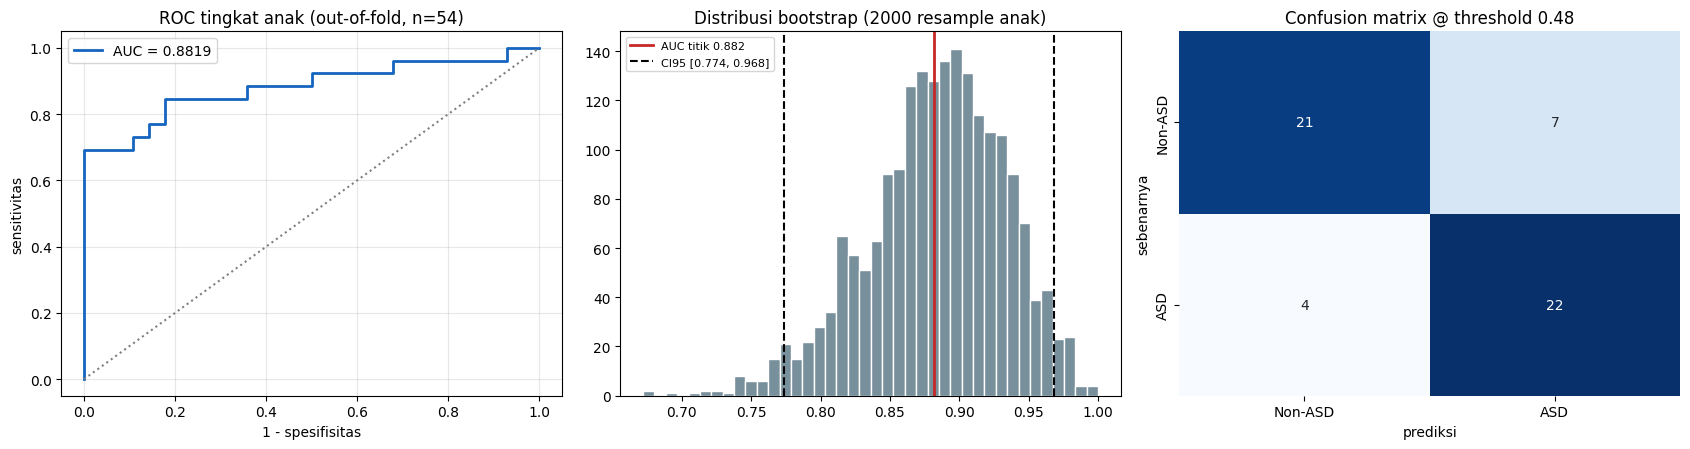

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

fpr, tpr, _ = roc_curve(oof_part.label, oof_part.p)
axes[0].plot(fpr, tpr, lw=2, color='#1565C0', label=f'AUC = {auc_oof:.4f}')
axes[0].plot([0,1],[0,1], ls=':', color='gray')
axes[0].set_xlabel('1 - spesifisitas'); axes[0].set_ylabel('sensitivitas')
axes[0].set_title('ROC tingkat anak (out-of-fold, n=54)'); axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].hist(dist, bins=40, color='#78909C', edgecolor='white')
axes[1].axvline(auc_oof, color='#C62828', lw=2, label=f'AUC titik {auc_oof:.3f}')
axes[1].axvline(lo, color='black', ls='--'); axes[1].axvline(hi, color='black', ls='--',
                                                             label=f'CI95 [{lo:.3f}, {hi:.3f}]')
axes[1].set_title(f'Distribusi bootstrap ({N_BOOTSTRAP} resample anak)'); axes[1].legend(fontsize=8)

sns.heatmap(confusion_matrix(oof_part.label, pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-ASD','ASD'], yticklabels=['Non-ASD','ASD'], ax=axes[2], cbar=False)
axes[2].set_xlabel('prediksi'); axes[2].set_ylabel('sebenarnya')
axes[2].set_title(f'Confusion matrix @ threshold {thr_pooled:.2f}')

plt.tight_layout(); plt.savefig('hasil_tingkat_anak.png', dpi=150); plt.show()

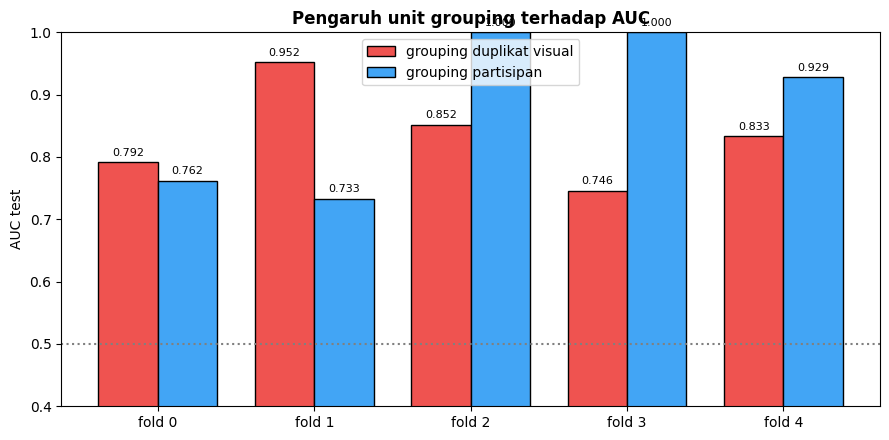

 fold  duplikat visual  partisipan
    0           0.7918      0.7619
    1           0.9524      0.7333
    2           0.8519      1.0000
    3           0.7459      1.0000
    4           0.8333      0.9286


In [15]:
if RUN_GROUPING_ABLATION:
    comp = pd.DataFrame({'fold': range(N_OUTER_FOLDS),
                         'duplikat visual': res_hash.auc_test.values,
                         'partisipan': res_part.auc_test.values})
    fig, ax = plt.subplots(figsize=(9, 4.5))
    x = np.arange(N_OUTER_FOLDS); w = 0.38
    ax.bar(x - w/2, comp['duplikat visual'], w, label='grouping duplikat visual',
           color='#EF5350', edgecolor='black')
    ax.bar(x + w/2, comp['partisipan'], w, label='grouping partisipan',
           color='#42A5F5', edgecolor='black')
    ax.axhline(0.5, ls=':', color='gray'); ax.set_xticks(x)
    ax.set_xticklabels([f'fold {i}' for i in x])
    ax.set_ylabel('AUC test'); ax.set_ylim(0.4, 1.0); ax.legend()
    ax.set_title('Pengaruh unit grouping terhadap AUC', fontweight='bold')
    for i, (a, b) in enumerate(zip(comp['duplikat visual'], comp['partisipan'])):
        ax.text(i - w/2, a + .01, f'{a:.3f}', ha='center', fontsize=8)
        ax.text(i + w/2, b + .01, f'{b:.3f}', ha='center', fontsize=8)
    plt.tight_layout(); plt.savefig('ablasi_grouping.png', dpi=150); plt.show()
    print(comp.round(4).to_string(index=False))

## 11. Ablasi: apakah fine-tuning membantu?

Selisih val AUC sebelum dan sesudah tahap fine-tuning diukur di semua fold. Pada dataset
sebesar ini, membuka sebagian backbone belum tentu memberi perbaikan yang berarti, dan
hasilnya dilaporkan apa adanya.

In [16]:
ft = res_part[['fold','auc_val_after_head','auc_val_after_finetune']].copy()
ft['delta'] = ft.auc_val_after_finetune - ft.auc_val_after_head
print(ft.round(4).to_string(index=False))
print(f'\nRata-rata perbaikan dari fine-tuning: {ft.delta.mean():+.4f} +/- {ft.delta.std():.4f}')
print('Jika mendekati nol, fine-tuning tidak memberi manfaat pada n=54.')
ft.to_csv('/kaggle/working/ablasi_finetune.csv', index=False)

 fold  auc_val_after_head  auc_val_after_finetune   delta
    0              0.9045                  0.9075  0.0030
    1              0.8296                  0.8282 -0.0013
    2              0.8146                  0.8127 -0.0019
    3              0.7341                  0.7385  0.0043
    4              0.9304                  0.9309  0.0004

Rata-rata perbaikan dari fine-tuning: +0.0009 +/- 0.0027
Jika mendekati nol, fine-tuning tidak memberi manfaat pada n=54.


## 12. Analisis kesalahan tingkat anak

Yang diperiksa adalah anak yang salah diklasifikasi, bukan citra. Untuk setiap anak
ditampilkan jumlah rekaman dan probabilitas rata-ratanya. Anak dengan sedikit rekaman
cenderung punya estimasi yang lebih bising.

Anak salah klasifikasi: 11/54

participant_id  label  prediction     p  n_records  fold
           S22      1           0 0.230          5     1
           S03      1           0 0.316         14     0
           S24      1           0 0.352         12     1
           S10      1           0 0.422         15     0
           C53      0           1 0.488          7     1
           C46      0           1 0.489          5     0
           C35      0           1 0.512         15     1
           C43      0           1 0.571          7     4
           C49      0           1 0.605          8     3
           C51      0           1 0.612          8     1
           C45      0           1 0.614          7     4


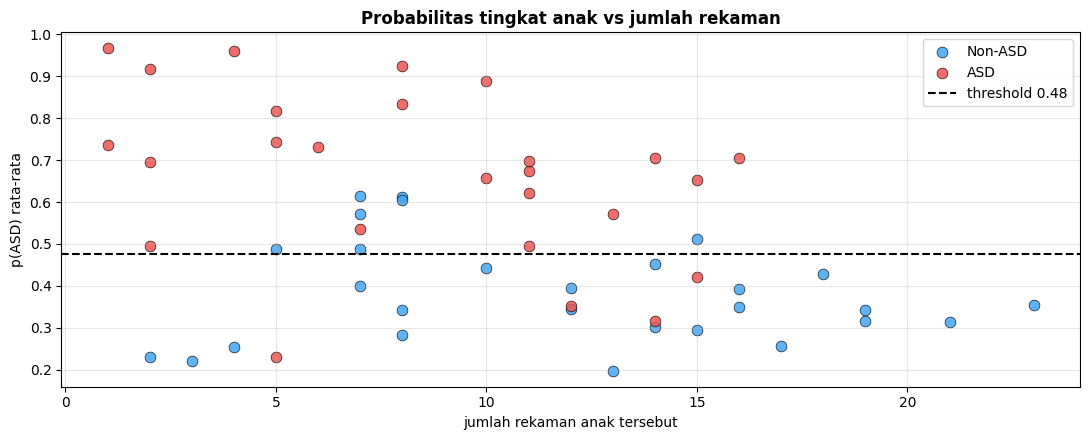

In [17]:
oof = oof_part.copy()
oof['prediction'] = (oof.p >= thr_pooled).astype(int)
err = oof[oof.label != oof.prediction].sort_values('p')
print(f'Anak salah klasifikasi: {len(err)}/{len(oof)}\n')
print(err[['participant_id','label','prediction','p','n_records','fold']].round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4.5))
for lbl, color, name in [(0, '#42A5F5', 'Non-ASD'), (1, '#EF5350', 'ASD')]:
    s = oof[oof.label == lbl]
    ax.scatter(s.n_records, s.p, c=color, s=60, edgecolor='black', linewidth=.5, label=name, alpha=.85)
ax.axhline(thr_pooled, ls='--', color='black', label=f'threshold {thr_pooled:.2f}')
ax.set_xlabel('jumlah rekaman anak tersebut'); ax.set_ylabel('p(ASD) rata-rata')
ax.set_title('Probabilitas tingkat anak vs jumlah rekaman', fontweight='bold')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig('error_analysis_anak.png', dpi=150); plt.show()

## 13. Ringkasan

Yang boleh diklaim:

- Performa tingkat anak dengan split terisolasi partisipan, 5 outer fold, disertai CI 95%.
- Besarnya inflasi akibat grouping duplikat visual sebagai temuan metodologis.
- Ada atau tidaknya manfaat fine-tuning pada ukuran sampel ini.

Yang tidak boleh diklaim:

- Performa klinis. Tidak ada validasi eksternal maupun prospektif.
- Relevansi langsung ke webapp. Model ini tidak diekspor: domain citra (raster scanpath
  250 Hz, anak usia sekolah) berbeda dari runtime web (koordinat iris kamera 20-30 Hz, balita).
- Evaluasi subkelompok demografis. Metadata usia, jenis kelamin, dan IQ tidak tersedia
  per anak pada rilis dataset ini.

In [18]:
print('='*68)
print('RINGKASAN — dataset eye-tracking Carette, evaluasi tingkat anak')
print('='*68)
print(f'Dataset            : {len(df)} citra scanpath, {df.participant_id.nunique()} anak '
      f'({int(child.label.sum())} ASD / {int((1-child.label).sum())} Non-ASD)')
print(f'Rekaman per anak   : min {rec_per_child.n_records.min()}, max {rec_per_child.n_records.max()}, '
      f'median {rec_per_child.n_records.median():.0f}')
print(f'Split              : nested StratifiedGroupKFold, groups = participant_id, {N_OUTER_FOLDS} outer fold')
print(f'Model              : EfficientNetB0 ImageNet, head 20 epoch + fine-tune 25% teratas 12 epoch')
print(f'Bobot              : equal-child (class weight dari jumlah anak / jumlah rekaman)')
print(f'Threshold          : dipilih pada validation tingkat anak, metrik {SELECTION_METRIC}')
print()
print(f'AUC tingkat anak   : {auc_oof:.4f}  (95% CI {lo:.4f}-{hi:.4f})')
print(f'AUC per fold       : {res_part.auc_test.mean():.4f} +/- {res_part.auc_test.std():.4f}')
print(f'Balanced accuracy  : {m_pooled["balanced_accuracy"]:.4f}')
print(f'Sensitivitas / Spes: {tp/(tp+fn):.4f} / {tn/(tn+fp):.4f} @ threshold {thr_pooled:.3f}')
if RUN_GROUPING_ABLATION:
    print()
    print(f'Ablasi grouping    : AUC dengan grouping duplikat visual {res_hash.auc_test.mean():.4f} '
          f'vs partisipan {res_part.auc_test.mean():.4f} '
          f'(inflasi {res_hash.auc_test.mean()-res_part.auc_test.mean():+.4f})')
    print(f'Anak menyeberang   : {ov_hash} pada grouping duplikat visual, {ov_part} pada grouping partisipan')
print(f'Ablasi fine-tuning : delta val AUC {ft.delta.mean():+.4f} +/- {ft.delta.std():.4f}')
print('='*68)

RINGKASAN — dataset eye-tracking Carette, evaluasi tingkat anak
Dataset            : 547 citra scanpath, 54 anak (26 ASD / 28 Non-ASD)
Rekaman per anak   : min 1, max 23, median 10
Split              : nested StratifiedGroupKFold, groups = participant_id, 5 outer fold
Model              : EfficientNetB0 ImageNet, head 20 epoch + fine-tune 25% teratas 12 epoch
Bobot              : equal-child (class weight dari jumlah anak / jumlah rekaman)
Threshold          : dipilih pada validation tingkat anak, metrik balanced_accuracy

AUC tingkat anak   : 0.8819  (95% CI 0.7738-0.9681)
AUC per fold       : 0.8848 +/- 0.1289
Balanced accuracy  : 0.7981
Sensitivitas / Spes: 0.8462 / 0.7500 @ threshold 0.476

Ablasi grouping    : AUC dengan grouping duplikat visual 0.8351 vs partisipan 0.8848 (inflasi -0.0497)
Anak menyeberang   : {'train/validation': 39, 'train/test': 41, 'validation/test': 35} pada grouping duplikat visual, {'train/validation': 0, 'train/test': 0, 'validation/test': 0} pada groupin